# Restaurant Sales — Executive Decision Dashboard
**IBM SkillsBuild Data Analytics with AI Internship 2026 | BharatCares x AICTE**

**Audience:** CEO / senior leadership of a multi-city restaurant chain
**Dataset:** Restaurant sales records, 7 Nov – 29 Dec 2022 (254 records, 5 cities, 5 products, 3 sales channels)
**Goal:** Turn raw sales records into a five-level decision dashboard: *KPI → Trends → Drivers → Risks → Actions*.

## Section 1 — Foundation: Business Context

Business Intelligence is the process of moving from raw records to a decision:

**Data → Information → Insight → Decision → Action**

| Stage | In this project |
|---|---|
| Data | 254 raw sales records (order, date, product, price, quantity, channel, payment, manager, city) |
| Information | Cleaned data, revenue calculated, KPIs and breakdowns |
| Insight | Which product, city and channel drive revenue, and where the business is exposed |
| Decision | Where to invest, what to protect, what to fix |
| Action | Specific recommendations for management (Section 6) |

**Business questions the CEO needs answered**
1. Is the business healthy right now? (KPIs)
2. Is it growing? (Trends)
3. What is driving revenue? (Drivers)
4. What could go wrong? (Risks)
5. What should we do next? (Actions)

In [1]:
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid.axis": "y"})

PRIMARY, ACCENT, GREY = "#1f4e79", "#e07b39", "#9aa5b1"
os.makedirs("charts", exist_ok=True)

def save(name):
    plt.savefig(f"charts/{name}.png", bbox_inches="tight", dpi=150)

metrics = {}   # every verified number is stored here and reused in the report and AI prompt

## Section 2 — Data Preparation

In [2]:
df = pd.read_csv("data/restaurant_sales.csv")
print("Shape:", df.shape)
df.head()

Shape: (254, 9)


,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
0,10452,07-11-2022,Fries,3.49,573.07,Online,Gift Card,Tom Jackson,London
1,10453,07-11-2022,Beverages,2.95,745.76,Online,Gift Card,Pablo Perez,Madrid
2,10454,07-11-2022,Sides & Other,4.99,200.40,In-store,Gift Card,Joao Silva,Lisbon
3,10455,08-11-2022,Burgers,12.99,569.67,In-store,Credit Card,Walter Muller,Berlin
4,10456,08-11-2022,Chicken Sandwiches,9.95,201.01,In-store,Credit Card,Walter Muller,Berlin


### 2.1 Quality checks (before touching anything)

In [3]:
print("Missing values per column:")
print(df.isna().sum().to_string(), "\n")
print("Duplicate rows      :", df.duplicated().sum())
print("Duplicate Order IDs :", df["Order ID"].duplicated().sum())
print("Manager spellings   :", df["Manager"].nunique(), "(should be 5 people)")
print("Purchase Type values:", df["Purchase Type"].unique().tolist(), "<- note the trailing spaces")
print("Date column dtype   :", df["Date"].dtype, "(should be datetime)")
print("Quantity is whole numbers?:", bool((df["Quantity"] % 1 == 0).all()))
df.dtypes.to_frame("dtype")

Missing values per column:
Order ID          0
Date              0
Product           0
Price             0
Quantity          0
Purchase Type     0
Payment Method    0
Manager           0
City              0 

Duplicate rows      : 0
Duplicate Order IDs : 0
Manager spellings   : 14 (should be 5 people)
Purchase Type values: ['Online ', 'In-store ', 'Drive-thru '] <- note the trailing spaces
Date column dtype   : str (should be datetime)
Quantity is whole numbers?: False


,dtype
Order ID,int64
Date,str
Product,str
Price,float64
Quantity,float64
Purchase Type,str
Payment Method,str
Manager,str
City,str


**What the checks show:** no missing values and no duplicates, but there are real quality problems to fix: stray spaces in text columns, inconsistent manager names, dates stored as text, decimal quantities, and suspicious prices. Each is handled below and documented.

### 2.2 Fix 1 — Text columns (stray spaces create fake categories)
Every `Purchase Type` and `Payment Method` value carries a trailing space (for example `'Online '`), and manager names contain extra internal spaces. Left alone, filters such as `== "Online"` silently return nothing.

In [4]:
text_cols = ["Product", "Purchase Type", "Payment Method", "Manager", "City"]

# rows affected, before cleaning
for c in text_cols:
    n_bad = (df[c] != df[c].str.split().str.join(" ")).sum()
    print(f"{c:15s} rows with stray spaces: {n_bad}")
metrics["purchase_type_space_rows"] = int((df["Purchase Type"] != df["Purchase Type"].str.strip()).sum())

before = df["Manager"].nunique()
for c in text_cols:
    df[c] = df[c].str.split().str.join(" ")     # trims edges and collapses internal spaces
after = df["Manager"].nunique()

print(f"\nManager spellings: {before} -> {after}")
print(df["Manager"].value_counts().to_string())
print("\nPurchase Type values:", sorted(df["Purchase Type"].unique()))
metrics["manager_spellings_before"] = int(before)
metrics["manager_spellings_after"] = int(after)

Product         rows with stray spaces: 0
Purchase Type   rows with stray spaces: 254
Payment Method  rows with stray spaces: 254
Manager         rows with stray spaces: 20
City            rows with stray spaces: 0

Manager spellings: 14 -> 5
Manager
Tom Jackson      75
Joao Silva       75
Pablo Perez      46
Walter Muller    30
Remy Monet       28

Purchase Type values: ['Drive-thru', 'In-store', 'Online']


### 2.3 Fix 2 — Dates
The dates are `dd-mm-yyyy` text. The format is stated explicitly, because otherwise pandas can silently swap day and month.

In [5]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")
print("Period:", df["Date"].min().date(), "to", df["Date"].max().date(), f"({df['Date'].nunique()} trading days)")

# Order IDs: are there gaps?
all_ids = set(range(df["Order ID"].min(), df["Order ID"].max() + 1))
missing_ids = sorted(all_ids - set(df["Order ID"]))
print("Missing Order IDs (gaps in the sequence):", missing_ids)

metrics["start"] = str(df["Date"].min().date())
metrics["end"] = str(df["Date"].max().date())
metrics["trading_days"] = int(df["Date"].nunique())
metrics["missing_order_ids"] = len(missing_ids)

Period: 2022-11-07 to 2022-12-29 (53 trading days)
Missing Order IDs (gaps in the sequence): [10458, 10469, 10517, 10518, 10519, 10587, 10588, 10589]


### 2.4 Fix 3 — Price anomalies
Each product should have one menu price. Two products show a second price that is far off the rest.

In [6]:
price_check = df.groupby("Product")["Price"].agg(["nunique", "min", "max"])
display(price_check)

standard_price = df.groupby("Product")["Price"].agg(lambda s: s.mode()[0])
df["Standard Price"] = df["Product"].map(standard_price)
df["Price Anomaly"] = df["Price"] != df["Standard Price"]

anomalies = df.loc[df["Price Anomaly"], ["Order ID", "Date", "Product", "Price", "Standard Price", "Quantity", "City"]]
display(anomalies)

,nunique,min,max
Product,,,
Beverages,1,2.95,2.95
Burgers,1,12.99,12.99
Chicken Sandwiches,2,9.95,29.05
Fries,2,3.49,25.50
Sides & Other,1,4.99,4.99


,Order ID,Date,Product,Price,Standard Price,Quantity,City
28,10482,2022-11-13,Fries,25.50,3.49,630.37,Lisbon
29,10486,2022-11-14,Chicken Sandwiches,29.05,9.95,201.01,Lisbon


**Decision:** Fries at 25.50 (menu price 3.49) and Chicken Sandwiches at 29.05 (menu price 9.95) are almost certainly data-entry errors, since the same products sell at one price in the other 100+ rows. I replace them with the menu price (the most frequent price) and keep the original as `Revenue Raw`, so the impact of this assumption is visible and reversible.

In [7]:
df["Revenue Raw"] = df["Price"] * df["Quantity"]
df["Revenue"] = df["Standard Price"] * df["Quantity"]

raw_total, clean_total = df["Revenue Raw"].sum(), df["Revenue"].sum()
print(f"Revenue using raw prices      : {raw_total:>12,.0f}")
print(f"Revenue using corrected prices: {clean_total:>12,.0f}")
print(f"Difference                    : {raw_total - clean_total:>12,.0f} ({(raw_total - clean_total) / raw_total:.1%} of raw)")

metrics["revenue_raw"] = float(raw_total)
metrics["price_anomaly_rows"] = int(df["Price Anomaly"].sum())
metrics["price_anomaly_impact"] = float(raw_total - clean_total)
metrics["price_anomaly_impact_pct"] = float((raw_total - clean_total) / raw_total * 100)

Revenue using raw prices      :      769,516
Revenue using corrected prices:      751,802
Difference                    :       17,714 (2.3% of raw)


### 2.5 Note on `Quantity`
Quantity holds decimals such as 573.07 and 200.40, and values repeat by product. Sold units cannot be fractional, so each row is most likely an **aggregated sales record** (for example a day's sales of one product at one location), not a single customer order. I keep the values as given and, in this report, use "order" to mean "sales record". This is listed as a limitation in Section 8.

## Section 3 — Level 1: Executive KPIs (*What is happening?*)

The masterclass rule: **every KPI must have a business purpose, otherwise remove it.**

| KPI | Above the fold? | Business purpose |
|---|---|---|
| **Total Revenue** | Yes | The single measure of business size. Answers "how much did we sell?" |
| **Growth %** | Yes | Direction. A large business that is shrinking is not healthy. Measured first full week to last full week. |
| **Average Order Value** | Yes | Revenue quality. It shows whether we sell high-value or low-value baskets, and it exposes the burger dependence found later. |
| Orders | No (Page 2) | Volume matters, but it is a driver of revenue, not a health check on its own. |
| Profit | **Not available** | The dataset has no cost data, so Profit cannot be calculated. Listed as a limitation. |
| Customers | **Not available** | There is no customer ID, so unique customers cannot be counted. |

In [8]:
# ---- weekly revenue (weeks end on Sunday); the last week is partial and is excluded from growth
df["Week Ending"] = df["Date"].dt.to_period("W-SUN").dt.end_time.dt.normalize()
weekly = (df.groupby("Week Ending")
            .agg(Revenue=("Revenue", "sum"), Orders=("Order ID", "count"), Days=("Date", "nunique"))
            .reset_index())
full_weeks = weekly[weekly["Days"] == 7].reset_index(drop=True)
partial_week = weekly[weekly["Days"] < 7].iloc[-1]

# ---- KPIs
total_revenue = df["Revenue"].sum()
total_orders = len(df)
aov = total_revenue / total_orders
first_wk, last_wk = full_weeks["Revenue"].iloc[0], full_weeks["Revenue"].iloc[-1]
growth_pct = (last_wk - first_wk) / first_wk * 100
avg_wow = full_weeks["Revenue"].pct_change().mean() * 100

daily_last_full = last_wk / 7
daily_partial = partial_week["Revenue"] / partial_week["Days"]

print(f"Total Revenue        : {total_revenue:,.0f}")
print(f"Orders (records)     : {total_orders}")
print(f"Average Order Value  : {aov:,.0f}")
print(f"Growth, first -> last full week: {growth_pct:+.1f}%  ({first_wk:,.0f} -> {last_wk:,.0f})")
print(f"Average week-on-week growth    : {avg_wow:+.1f}%")
print(f"Last full week daily run-rate  : {daily_last_full:,.0f}")
print(f"Final partial week ({int(partial_week['Days'])} days) run-rate: {daily_partial:,.0f}")

metrics.update({
    "total_revenue": float(total_revenue), "orders": int(total_orders), "aov": float(aov),
    "first_week_rev": float(first_wk), "last_week_rev": float(last_wk),
    "growth_pct": float(growth_pct), "avg_wow_pct": float(avg_wow),
    "daily_last_full": float(daily_last_full), "daily_partial": float(daily_partial),
    "partial_days": int(partial_week["Days"]), "full_weeks": int(len(full_weeks)),
})

Total Revenue        : 751,802
Orders (records)     : 254
Average Order Value  : 2,960
Growth, first -> last full week: +30.5%  (87,200 -> 113,800)
Average week-on-week growth    : +4.7%
Last full week daily run-rate  : 16,257
Final partial week (4 days) run-rate: 17,100


## Page 1 — Executive Overview

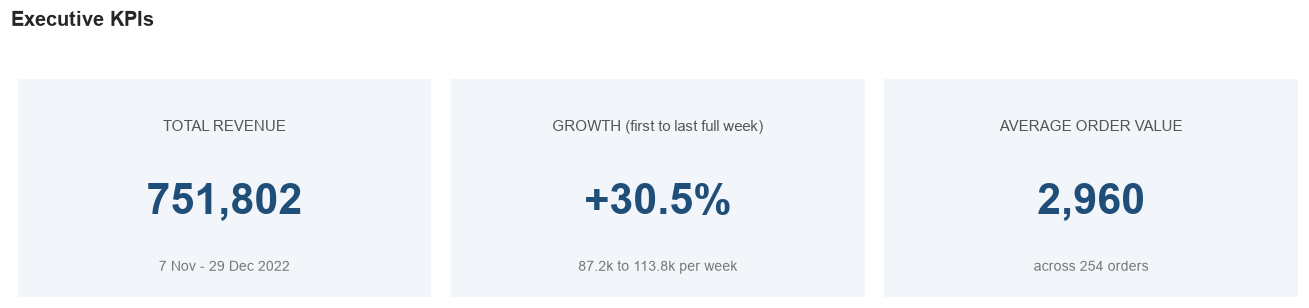

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 2.7))
tiles = [
    ("TOTAL REVENUE", f"{total_revenue:,.0f}", "7 Nov - 29 Dec 2022"),
    ("GROWTH (first to last full week)", f"{growth_pct:+.1f}%", f"{first_wk/1000:,.1f}k to {last_wk/1000:,.1f}k per week"),
    ("AVERAGE ORDER VALUE", f"{aov:,.0f}", f"across {total_orders} orders"),
]
for ax, (title, value, sub) in zip(axes, tiles):
    ax.axis("off")
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, color="#f2f5f9", zorder=0))
    ax.text(0.5, 0.76, title, ha="center", fontsize=10, color="#555", transform=ax.transAxes)
    ax.text(0.5, 0.38, value, ha="center", fontsize=28, weight="bold", color=PRIMARY, transform=ax.transAxes)
    ax.text(0.5, 0.12, sub, ha="center", fontsize=9, color="#777", transform=ax.transAxes)
plt.suptitle("Executive KPIs", x=0.01, ha="left", fontsize=13, weight="bold", y=1.03)
plt.tight_layout()
save("01_kpi_tiles")
plt.show()

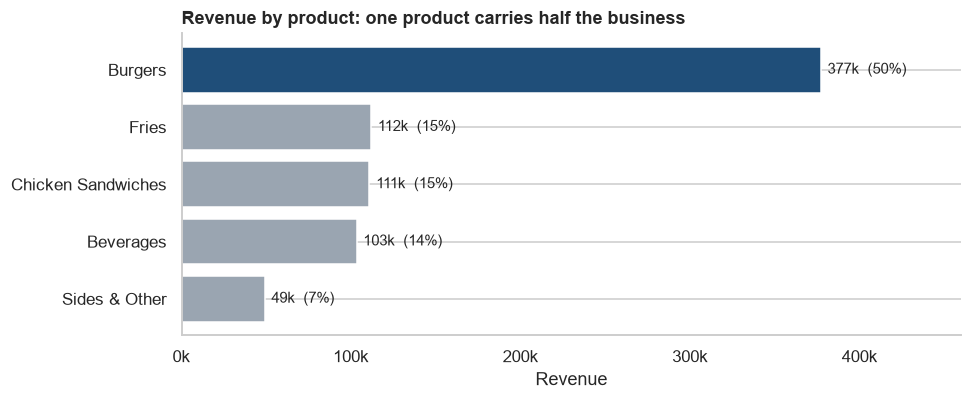

,Revenue,Orders,Share,AOV
Product,,,,
Burgers,376999.8,52,50.1,7250.0
Fries,111799.8,51,14.9,2192.2
Chicken Sandwiches,110802.4,52,14.7,2130.8
Beverages,103200.3,50,13.7,2064.0
Sides & Other,48999.8,49,6.5,1000.0



INSIGHT: Burgers = 50% of revenue from 52 of 254 orders. A Burgers order is worth 7,250 vs 1,855 for all other products.


In [10]:
# ---- revenue by product (used on Page 1 and Page 2)
prod = (df.groupby("Product")
          .agg(Revenue=("Revenue", "sum"), Orders=("Order ID", "count"))
          .assign(Share=lambda d: d["Revenue"] / d["Revenue"].sum() * 100,
                  AOV=lambda d: d["Revenue"] / d["Orders"])
          .sort_values("Revenue", ascending=False))

fig, ax = plt.subplots(figsize=(9, 3.8))
bars = ax.barh(prod.index[::-1], prod["Revenue"][::-1], color=[PRIMARY if p == prod.index[0] else GREY for p in prod.index[::-1]])
for bar, (rev, sh) in zip(bars, zip(prod["Revenue"][::-1], prod["Share"][::-1])):
    ax.text(bar.get_width() + 4000, bar.get_y() + bar.get_height() / 2, f"{rev/1000:,.0f}k  ({sh:.0f}%)", va="center", fontsize=10)
ax.set_xlim(0, prod["Revenue"].max() * 1.22)
ax.xaxis.set_major_formatter(lambda x, _: f"{x/1000:,.0f}k")
ax.set_title("Revenue by product: one product carries half the business", loc="left", weight="bold")
ax.set_xlabel("Revenue")
plt.tight_layout()
save("02_revenue_by_product")
plt.show()

display(prod.round(1))

top_prod, top_share = prod.index[0], prod["Share"].iloc[0]
rest_aov = df.loc[df["Product"] != top_prod, "Revenue"].sum() / (df["Product"] != top_prod).sum()
print(f"\nINSIGHT: {top_prod} = {top_share:.0f}% of revenue from {prod['Orders'].iloc[0]} of {total_orders} orders. "
      f"A {top_prod} order is worth {prod['AOV'].iloc[0]:,.0f} vs {rest_aov:,.0f} for all other products.")

metrics["top_product"] = top_prod
metrics["top_product_share"] = float(top_share)
metrics["top_product_aov"] = float(prod["AOV"].iloc[0])
metrics["other_products_aov"] = float(rest_aov)
metrics["product_table"] = prod.round(1).reset_index().to_dict(orient="records")

## Page 2 — Sales & Product Analysis

### Level 2: Trends (*How is it changing?*)

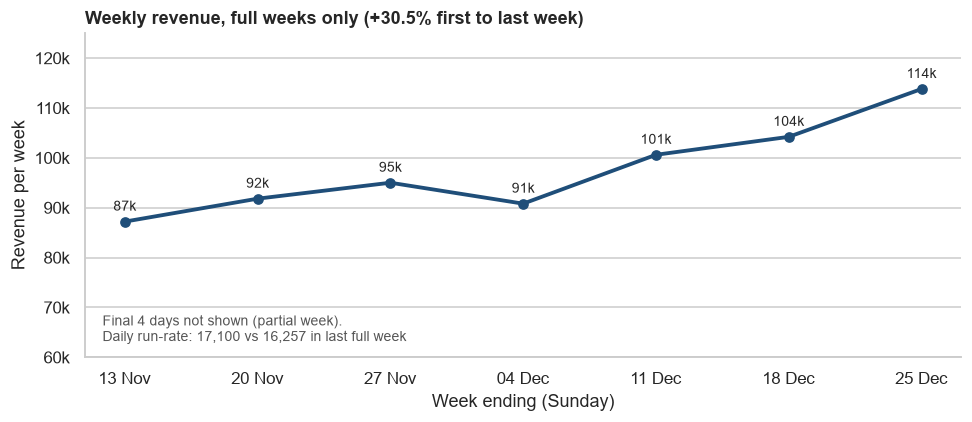

INSIGHT: revenue rose in 5 of 6 week-on-week comparisons; average +4.7% per week.
Caution: 7 full weeks include the December holiday period, so part of this growth may be seasonal.


In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(full_weeks["Week Ending"], full_weeks["Revenue"], marker="o", color=PRIMARY, lw=2.5)
for x, y in zip(full_weeks["Week Ending"], full_weeks["Revenue"]):
    ax.text(x, y + 2200, f"{y/1000:,.0f}k", ha="center", fontsize=9)
ax.set_ylim(60000, 125000)
ax.yaxis.set_major_formatter(lambda x, _: f"{x/1000:,.0f}k")
ax.set_xticks(full_weeks["Week Ending"])
ax.set_xticklabels(full_weeks["Week Ending"].dt.strftime("%d %b"))
ax.set_title(f"Weekly revenue, full weeks only ({growth_pct:+.1f}% first to last week)", loc="left", weight="bold")
ax.set_ylabel("Revenue per week")
ax.set_xlabel("Week ending (Sunday)")
ax.annotate(f"Final {int(partial_week['Days'])} days not shown (partial week).\nDaily run-rate: {daily_partial:,.0f} vs {daily_last_full:,.0f} in last full week",
            xy=(0.02, 0.05), xycoords="axes fraction", fontsize=9, color="#555")
plt.tight_layout()
save("03_weekly_trend")
plt.show()

trend_ok = (full_weeks["Revenue"].diff().dropna() > 0).sum()
print(f"INSIGHT: revenue rose in {trend_ok} of {len(full_weeks)-1} week-on-week comparisons; average {avg_wow:+.1f}% per week.")
print("Caution: 7 full weeks include the December holiday period, so part of this growth may be seasonal.")
metrics["weeks_up"] = int(trend_ok)

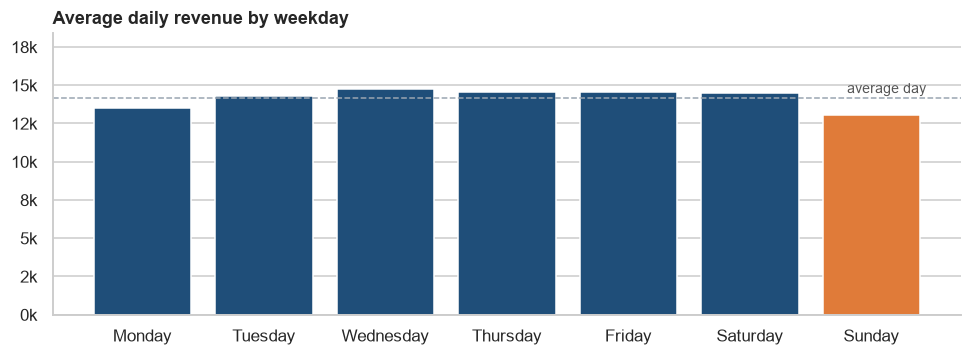

INSIGHT: Sunday is the weakest day, 8% below the average day.


In [12]:
# ---- day-of-week pattern (average daily revenue, so weekdays with more dates are not favoured)
daily = df.groupby("Date")["Revenue"].sum()
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow = daily.groupby(daily.index.day_name()).mean().reindex(order)

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(dow.index, dow.values, color=[ACCENT if d == dow.idxmin() else PRIMARY for d in dow.index])
ax.axhline(daily.mean(), color=GREY, ls="--", lw=1)
ax.set_ylim(0, dow.max() * 1.25)
ax.text(6.45, daily.mean() + 300, "average day", ha="right", fontsize=9, color="#555")
ax.yaxis.set_major_formatter(lambda x, _: f"{x/1000:,.0f}k")
ax.set_title("Average daily revenue by weekday", loc="left", weight="bold")
plt.tight_layout()
save("04_weekday_pattern")
plt.show()

weakest = dow.idxmin()
gap = (dow.min() / daily.mean() - 1) * 100
print(f"INSIGHT: {weakest} is the weakest day, {abs(gap):.0f}% below the average day.")
metrics["weakest_day"] = weakest
metrics["weakest_day_gap_pct"] = float(gap)
metrics["avg_daily_revenue"] = float(daily.mean())

### Level 3: Drivers (*Why?*) — city, channel and product mix

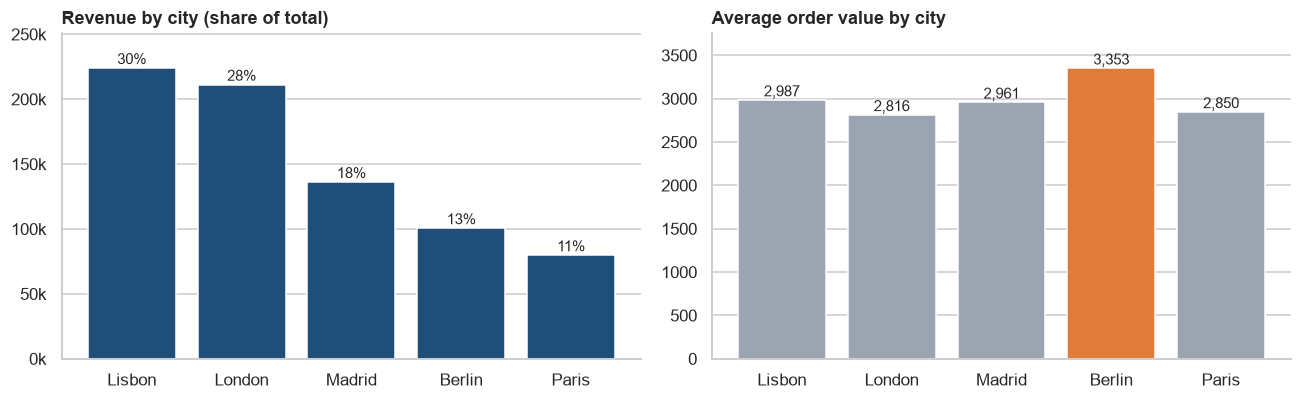

,Revenue,Orders,Share,AOV
City,,,,
Lisbon,224000.4,75,29.8,2986.7
London,211201.0,75,28.1,2816.0
Madrid,136200.3,46,18.1,2960.9
Berlin,100600.1,30,13.4,3353.3
Paris,79800.3,28,10.6,2850.0


INSIGHT: Lisbon and London generate 58% of revenue. Berlin has the highest average order value (3,353) but only 13% of revenue.


In [13]:
city = (df.groupby("City")
          .agg(Revenue=("Revenue", "sum"), Orders=("Order ID", "count"))
          .assign(Share=lambda d: d["Revenue"] / d["Revenue"].sum() * 100,
                  AOV=lambda d: d["Revenue"] / d["Orders"])
          .sort_values("Revenue", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].bar(city.index, city["Revenue"], color=PRIMARY)
for i, (r, s) in enumerate(zip(city["Revenue"], city["Share"])):
    axes[0].text(i, r + 3000, f"{s:.0f}%", ha="center", fontsize=10)
axes[0].set_ylim(0, city["Revenue"].max() * 1.12)
axes[1].set_ylim(0, city["AOV"].max() * 1.12)
axes[0].yaxis.set_major_formatter(lambda x, _: f"{x/1000:,.0f}k")
axes[0].set_title("Revenue by city (share of total)", loc="left", weight="bold")

axes[1].bar(city.index, city["AOV"], color=[ACCENT if c == city["AOV"].idxmax() else GREY for c in city.index])
for i, a in enumerate(city["AOV"]):
    axes[1].text(i, a + 40, f"{a:,.0f}", ha="center", fontsize=10)
axes[1].set_title("Average order value by city", loc="left", weight="bold")
plt.tight_layout()
save("05_city_revenue_aov")
plt.show()

display(city.round(1))

top2_share = city["Share"].iloc[:2].sum()
print(f"INSIGHT: {city.index[0]} and {city.index[1]} generate {top2_share:.0f}% of revenue. "
      f"{city['AOV'].idxmax()} has the highest average order value ({city['AOV'].max():,.0f}) but only {city.loc[city['AOV'].idxmax(), 'Share']:.0f}% of revenue.")
metrics["city_table"] = city.round(1).reset_index().to_dict(orient="records")
metrics["top2_cities"] = [city.index[0], city.index[1]]
metrics["top2_city_share"] = float(top2_share)
metrics["best_aov_city"] = city["AOV"].idxmax()
metrics["best_aov_city_value"] = float(city["AOV"].max())

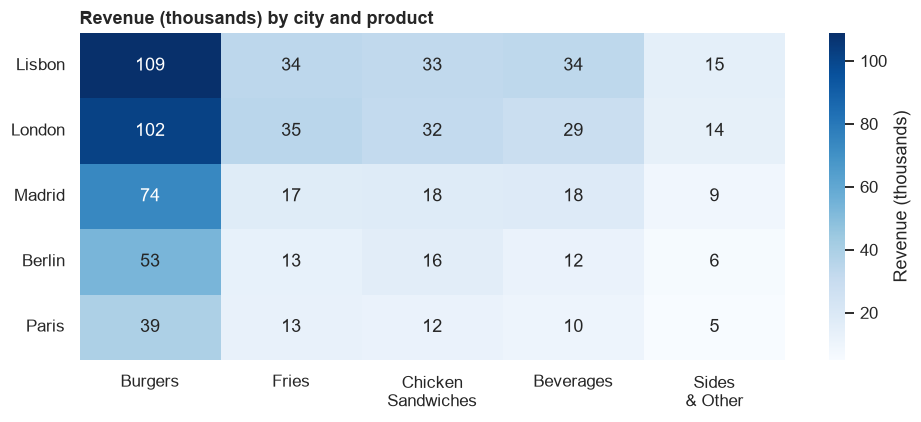

INSIGHT: Burgers lead in every city, so the burger dependence is a chain-wide pattern and not one weak market.


In [14]:
# ---- product x city heatmap
pc = df.pivot_table(index="City", columns="Product", values="Revenue", aggfunc="sum").loc[city.index, prod.index]
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(pc / 1000, annot=True, fmt=".0f", cmap="Blues", cbar_kws={"label": "Revenue (thousands)"}, ax=ax)
ax.set_title("Revenue (thousands) by city and product", loc="left", weight="bold")
ax.set_xlabel(""); ax.set_ylabel("")
ax.set_xticklabels([t.get_text().replace(" ", "\n", 1) for t in ax.get_xticklabels()], rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.grid(False)
plt.tight_layout()
save("06_product_city_heatmap")
plt.show()
print("INSIGHT: Burgers lead in every city, so the burger dependence is a chain-wide pattern and not one weak market.")
metrics["burgers_top_every_city"] = bool((pc.idxmax(axis=1) == "Burgers").all())

,Revenue,Orders,Share,AOV
Purchase Type,,,,
Online,305201.4,107,40.6,2852.3
In-store,268000.3,86,35.6,3116.3
Drive-thru,178600.5,61,23.8,2927.9


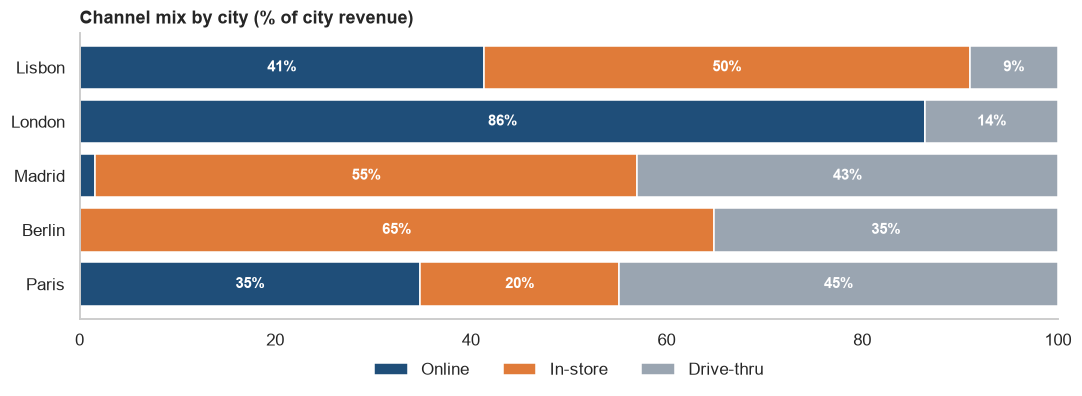

INSIGHT 1: Online is the largest channel (41% of revenue).
INSIGHT 2: London earns 86% of its revenue online and has no in-store sales.
INSIGHT 3: Berlin has 0 online revenue and Madrid only 1.6% of its revenue online, although Berlin has the highest order value.


In [15]:
# ---- channel mix: overall and by city
chan = (df.groupby("Purchase Type")
          .agg(Revenue=("Revenue", "sum"), Orders=("Order ID", "count"))
          .assign(Share=lambda d: d["Revenue"] / d["Revenue"].sum() * 100,
                  AOV=lambda d: d["Revenue"] / d["Orders"])
          .sort_values("Revenue", ascending=False))
display(chan.round(1))

cc = df.pivot_table(index="City", columns="Purchase Type", values="Revenue", aggfunc="sum", fill_value=0).loc[city.index]
cc_pct = cc.div(cc.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 3.8))
colors = {"Online": PRIMARY, "In-store": ACCENT, "Drive-thru": GREY}
left = pd.Series(0.0, index=cc_pct.index)
for ch in ["Online", "In-store", "Drive-thru"]:
    ax.barh(cc_pct.index, cc_pct[ch], left=left, color=colors[ch], label=ch)
    for c in cc_pct.index:
        v = cc_pct.loc[c, ch]
        if v >= 6:
            ax.text(left[c] + v / 2, c, f"{v:.0f}%", ha="center", va="center", color="white", fontsize=10, weight="bold")
    left = left + cc_pct[ch]
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_title("Channel mix by city (% of city revenue)", loc="left", weight="bold")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.1), frameon=False)
plt.tight_layout()
save("07_channel_mix_by_city")
plt.show()

online_share = chan.loc["Online", "Share"]
london_online = cc_pct.loc["London", "Online"]
berlin_online = cc.loc["Berlin", "Online"] if "Online" in cc.columns else 0
madrid_online_share = cc_pct.loc["Madrid", "Online"]
print(f"INSIGHT 1: Online is the largest channel ({online_share:.0f}% of revenue).")
print(f"INSIGHT 2: London earns {london_online:.0f}% of its revenue online and has no in-store sales.")
print(f"INSIGHT 3: Berlin has {berlin_online:,.0f} online revenue and Madrid only {madrid_online_share:.1f}% of its revenue online, "
      f"although Berlin has the highest order value.")

metrics["channel_table"] = chan.round(1).reset_index().to_dict(orient="records")
metrics["online_share"] = float(online_share)
metrics["london_online_share"] = float(london_online)
metrics["london_instore_rev"] = float(cc.loc["London", "In-store"]) if "In-store" in cc.columns else 0.0
metrics["berlin_online_rev"] = float(berlin_online)
metrics["madrid_online_share"] = float(madrid_online_share)

## Page 3 — Customer & Risk Analysis

**Scope note:** the data has no customer ID, so customer behaviour (repeat purchase, churn, lifetime value) cannot be analysed. The nearest available view of "how customers buy" is *channel* and *payment method*.

### Payment behaviour

,Revenue,Orders,Share,AOV
Payment Method,,,,
Credit Card,344001.3,120,45.8,2866.7
Cash,239200.2,76,31.8,3147.4
Gift Card,168600.6,58,22.4,2906.9


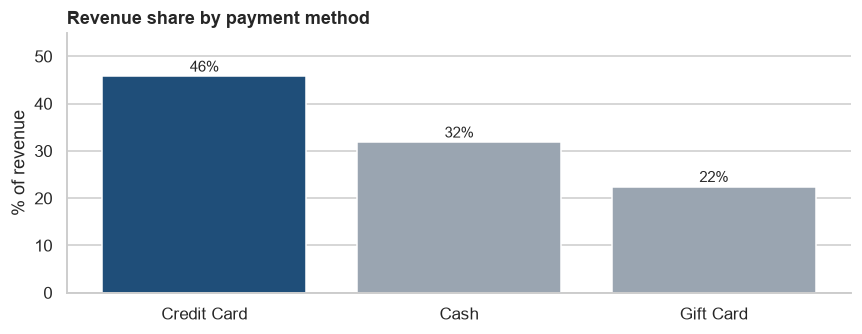

In [16]:
pay = (df.groupby("Payment Method")
         .agg(Revenue=("Revenue", "sum"), Orders=("Order ID", "count"))
         .assign(Share=lambda d: d["Revenue"] / d["Revenue"].sum() * 100,
                 AOV=lambda d: d["Revenue"] / d["Orders"])
         .sort_values("Revenue", ascending=False))
display(pay.round(1))

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(pay.index, pay["Share"], color=[PRIMARY, GREY, GREY])
for i, s in enumerate(pay["Share"]):
    ax.text(i, s + 1, f"{s:.0f}%", ha="center", fontsize=10)
ax.set_ylim(0, pay["Share"].max() * 1.2)
ax.set_title("Revenue share by payment method", loc="left", weight="bold")
ax.set_ylabel("% of revenue")
plt.tight_layout()
save("08_payment_mix")
plt.show()

metrics["payment_table"] = pay.round(1).reset_index().to_dict(orient="records")
metrics["gift_card_share"] = float(pay.loc["Gift Card", "Share"])
metrics["credit_share"] = float(pay.loc["Credit Card", "Share"])

### Level 4: Risk (*What could go wrong?*) — concentration and data-quality scorecard

In [17]:
# managers and cities are the same dimension in this data
one_to_one = bool((df.groupby("City")["Manager"].nunique() == 1).all() and (df.groupby("Manager")["City"].nunique() == 1).all())
print("Each manager runs exactly one city:", one_to_one)
metrics["manager_city_one_to_one"] = one_to_one

risk = pd.DataFrame([
    ["Product concentration", f"{top_prod} share of revenue", f"{top_share:.0f}%"],
    ["City concentration", f"{city.index[0]} + {city.index[1]} share of revenue", f"{top2_share:.0f}%"],
    ["Channel dependence", f"London revenue from online", f"{london_online:.0f}%"],
    ["Channel gap", f"Berlin online revenue / Madrid online share", f"{berlin_online:,.0f} / {madrid_online_share:.1f}%"],
    ["Data quality", "Revenue affected by price anomalies", f"{metrics['price_anomaly_impact_pct']:.1f}%"],
    ["Data quality", "Missing Order IDs in sequence", f"{len(missing_ids)}"],
], columns=["Risk area", "Measure", "Value"])
risk

Each manager runs exactly one city: True


,Risk area,Measure,Value
0,Product concentration,Burgers share of revenue,50%
1,City concentration,Lisbon + London share of revenue,58%
2,Channel dependence,London revenue from online,86%
3,Channel gap,Berlin online revenue / Madrid online share,0 / 1.6%
4,Data quality,Revenue affected by price anomalies,2.3%
5,Data quality,Missing Order IDs in sequence,8


## Section 6 — Level 5: Risk → Opportunity → Action

Every row is built from a number computed above, so each recommendation can be traced to a chart.

In [18]:
sides_share = prod.loc["Sides & Other", "Share"]
sides_aov = prod.loc["Sides & Other", "AOV"]

recs = pd.DataFrame([
    ["Risk",
     f"{top_prod} generate {top_share:.0f}% of revenue and are the top product in every city. One supply, price or quality problem would hit half the business.",
     f"Secure {top_prod.lower()} supply and pricing; track {top_prod.lower()} share monthly with an alert if it moves sharply."],
    ["Risk",
     f"{city.index[0]} and {city.index[1]} produce {top2_share:.0f}% of revenue, and London earns {london_online:.0f}% of its revenue online with no in-store sales.",
     "Set up a contingency plan for the two anchor cities, including online platform uptime and delivery capacity in London."],
    ["Opportunity",
     f"Online is the largest channel ({online_share:.0f}% of revenue), yet Berlin has no online revenue and Madrid only {madrid_online_share:.1f}%. Berlin has the highest order value ({metrics['best_aov_city_value']:,.0f}).",
     "Pilot online ordering in Berlin and Madrid; measure new online revenue after 4 weeks against the in-store baseline."],
    ["Opportunity",
     f"Sides & Other is only {sides_share:.0f}% of revenue at {sides_aov:,.0f} per order, the lowest of all products.",
     f"Bundle Sides & Other and Fries with {top_prod} in combo offers to raise order value."],
    ["Opportunity",
     f"Weekly revenue grew {growth_pct:+.1f}% and the final partial week has the highest daily run-rate ({daily_partial:,.0f}/day). {weakest} is the weakest weekday ({abs(gap):.0f}% below average).",
     f"Run a targeted {weakest} promotion; re-check growth once January and later data is available to separate trend from holiday season."],
    ["Action (data)",
     f"{metrics['price_anomaly_rows']} rows had invalid prices (about {metrics['price_anomaly_impact_pct']:.1f}% of raw revenue) and {len(missing_ids)} Order IDs are missing.",
     "Add price validation at order entry and audit the missing Order IDs (possible cancelled or unrecorded orders)."],
], columns=["Category", "Finding (evidence)", "Recommended action"])

pd.set_option("display.max_colwidth", None)
display(recs.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "pre-wrap"}))
metrics["recommendations"] = recs.to_dict(orient="records")

Category,Finding (evidence),Recommended action
Risk,"Burgers generate 50% of revenue and are the top product in every city. One supply, price or quality problem would hit half the business.",Secure burgers supply and pricing; track burgers share monthly with an alert if it moves sharply.
Risk,"Lisbon and London produce 58% of revenue, and London earns 86% of its revenue online with no in-store sales.","Set up a contingency plan for the two anchor cities, including online platform uptime and delivery capacity in London."
Opportunity,"Online is the largest channel (41% of revenue), yet Berlin has no online revenue and Madrid only 1.6%. Berlin has the highest order value (3,353).",Pilot online ordering in Berlin and Madrid; measure new online revenue after 4 weeks against the in-store baseline.
Opportunity,"Sides & Other is only 7% of revenue at 1,000 per order, the lowest of all products.",Bundle Sides & Other and Fries with Burgers in combo offers to raise order value.
Opportunity,"Weekly revenue grew +30.5% and the final partial week has the highest daily run-rate (17,100/day). Sunday is the weakest weekday (8% below average).",Run a targeted Sunday promotion; re-check growth once January and later data is available to separate trend from holiday season.
Action (data),2 rows had invalid prices (about 2.3% of raw revenue) and 8 Order IDs are missing.,Add price validation at order entry and audit the missing Order IDs (possible cancelled or unrecorded orders).


## Section 7 — AI as Executive Analyst (Gemini)

Rules from the masterclass: **give the AI only verified metrics**, and **validate every conclusion against the dashboard**.

**Method.** The cell below builds a prompt from numbers computed and verified in this notebook, and prints it. No raw data was given to the AI. The prompt was pasted into Gemini and its full response is in 7.1. Each claim was then checked against the charts and tables above and marked Confirmed, Rejected or Unsupported in 7.2.

In [19]:
verified = f"""
VERIFIED METRICS (restaurant chain, 7 Nov - 29 Dec 2022, 5 cities, 5 products, 3 channels)
- Total revenue: {total_revenue:,.0f} from {total_orders} sales records; average order value {aov:,.0f}
- Weekly revenue grew {growth_pct:+.1f}% from first to last full week ({first_wk:,.0f} to {last_wk:,.0f}); revenue rose in {metrics['weeks_up']} of {len(full_weeks)-1} weekly comparisons
- Products by revenue share: {', '.join(f"{p} {s:.0f}%" for p, s in prod['Share'].items())}
- Average order value by product: {', '.join(f"{p} {a:,.0f}" for p, a in prod['AOV'].items())}
- Cities by revenue share: {', '.join(f"{c} {s:.0f}%" for c, s in city['Share'].items())}
- Average order value by city: {', '.join(f"{c} {a:,.0f}" for c, a in city['AOV'].items())}
- Channel share of revenue: {', '.join(f"{c} {s:.0f}%" for c, s in chan['Share'].items())}
- London earns {london_online:.0f}% of its revenue online; Berlin online revenue = {berlin_online:,.0f}; Madrid online share = {madrid_online_share:.1f}%
- Payment share: {', '.join(f"{c} {s:.0f}%" for c, s in pay['Share'].items())}
- Weakest weekday: {weakest} ({abs(gap):.0f}% below the average day)
- Limitations: no profit or cost data, no customer IDs, only 53 days of data
"""

prompt = f"""You are an executive business analyst advising the CEO of a restaurant chain.
Use ONLY the verified metrics below. Do not invent numbers.

{verified}
Produce:
1. 5 Key Findings - the most important patterns in the data
2. 3 Risks - what could hurt the business
3. 3 Opportunities - where the business could grow
4. 5 Recommended Actions - what management should consider doing
Keep each item to one or two sentences and cite the metric it relies on."""

print(prompt)
metrics["ai_prompt"] = prompt

You are an executive business analyst advising the CEO of a restaurant chain.
Use ONLY the verified metrics below. Do not invent numbers.


VERIFIED METRICS (restaurant chain, 7 Nov - 29 Dec 2022, 5 cities, 5 products, 3 channels)
- Total revenue: 751,802 from 254 sales records; average order value 2,960
- Weekly revenue grew +30.5% from first to last full week (87,200 to 113,800); revenue rose in 5 of 6 weekly comparisons
- Products by revenue share: Burgers 50%, Fries 15%, Chicken Sandwiches 15%, Beverages 14%, Sides & Other 7%
- Average order value by product: Burgers 7,250, Fries 2,192, Chicken Sandwiches 2,131, Beverages 2,064, Sides & Other 1,000
- Cities by revenue share: Lisbon 30%, London 28%, Madrid 18%, Berlin 13%, Paris 11%
- Average order value by city: Lisbon 2,987, London 2,816, Madrid 2,961, Berlin 3,353, Paris 2,850
- Channel share of revenue: Online 41%, In-store 36%, Drive-thru 24%
- London earns 86% of its revenue online; Berlin online revenue = 0; Madrid online sha

### 7.1 Gemini's Answer

Key Findings

1. Consistent Revenue Growth: Weekly revenue increased +30.5% from the first full week to the last full week (87,200 to 113,800), with revenue rising in 5 of 6 weekly comparisons over the 53-day period.
2. Burger Category Dominance: Burgers generate 50% of total revenue and command an average order value of 7,250, significantly outperforming Sides & Other, which account for just 7% of revenue and an average order value of 1,000.
3. Geographic Concentration in Two Markets: Lisbon (30%) and London (28%) combined generate 58% of overall sales, while Paris represents the smallest market share at 11%.
4. Digital Ordering Drives Fulfillment: Online is the leading revenue channel overall at 41%, outpacing In-store (36%) and Drive-thru (24%).
5. Extreme Geographic Disparities in Channel Adoption: Digital maturity varies dramatically across markets, with London earning 86% of its revenue online compared to just 1.6% in Madrid and 0% in Berlin.

Risks

1. Concentration Risk on Core Product: Generating 50% of total revenue from Burgers leaves overall performance highly vulnerable to ingredient supply disruptions or input cost inflation.
2. Competitor Exposure from Digital Blackouts: Recording zero online revenue in Berlin and only 1.6% in Madrid creates significant risk of losing market share to digital-first competitors in those cities.
3. Weekend Revenue Slack: Sunday performance lags behind the rest of the week, running 8% below the average day across the 254 sales records analyzed.

Opportunities

1. Digital Expansion in Low-Adoption Cities: Establishing online infrastructure in Berlin (currently 0% online revenue) and expanding it in Madrid (1.6%) offers an immediate path to overall growth based on London’s 86% online share.
2. Leveraging High-Ticket Customers in Berlin: Berlin yields the highest average order value of any market at 3,353 (above the overall average of 2,960), indicating strong upside if transaction volume can be expanded beyond its current 13% revenue share.
3. Cross-Selling to Elevate Low-AOV Categories: Bundling lower-value items like Sides & Other (1,000 average order value, 7% share) with high-performing Burgers (7,250 average order value) can increase total ticket size.

Recommended Actions

1. Deploy Digital Fulfillment Infrastructure in Berlin and Madrid: Establish online ordering capabilities to bridge the gap between Berlin (0% online) and Madrid (1.6% online) and the network-wide 41% online channel baseline.
2. Implement Strategic Burger Bundling: Leverage the strong demand for Burgers (50% revenue share, 7,250 average order value) by creating attachments with low-performing Sides & Other (7% revenue share) to raise overall ticket values.
3. Execute Targeted Sunday Daypart Promotions: Introduce Sunday-only incentives to close the 8% revenue gap relative to the average day.
4. Replicate London’s E-Commerce Playbook in Lisbon: Adapt London’s operational model (86% online revenue share) to Lisbon, which is already the top revenue market at 30% share.
5. Integrate Margin and Customer Tracking Systems: Expand reporting infrastructure beyond the initial 53-day dataset to track cost/profit data and customer IDs for unit economics and lifetime value calculations.

### 7.2 Validation against the dashboard

| # | AI claim (short) | Verdict | Evidence from this notebook |
|---|---|---|---|
| 1 | Burgers generate 50% of revenue with average order value 7,250 (Finding 2) | Confirmed | Figure 2: Burgers 50%, 7,250 per order |
| 2 | Online is the top channel at 41%; London 86% online, Madrid 1.6%, Berlin 0 (Findings 4 and 5) | Confirmed | Figure 7 and the channel table |
| 3 | "Weekend revenue slack": Sunday lags the week (Risk 3) | Rejected | Only Sunday is below average (about 8%). Saturday is 2.3% above average, and Monday is also below (Figure 4) |
| 4 | Burger dependence exposes the business to supply disruption or cost inflation (Risk 1) | Unsupported | The 50% share is confirmed, but the data has no cost or supply information |
| 5 | Replicate London's online model in Lisbon (Action 4) | Rejected | Lisbon already earns 41% of its revenue online and 50% in-store (Figure 7), so the premise does not hold |

**Reflection:** *Gemini reproduced the supplied numbers accurately, including revenue shares, order values and channel splits. It overreached in three ways: it called the weekend weak when only Sunday is below average, it suggested cost and supply causes that the data cannot show, and it recommended copying London's model in Lisbon without knowing Lisbon already earns 41% of its revenue online. AI is useful for drafting a summary, but every claim still needs to be checked against the dashboard.*

## Section 8 — Limitations

1. **No profit or cost data.** Profit cannot be calculated, so "healthy" here means revenue health, not margin health.
2. **No customer ID.** Customer count, retention and churn cannot be measured. Channel and payment method are used as proxies for buying behaviour.
3. **Short period (53 days) that includes the December holiday season.** The growth figure may partly reflect seasonality and is not a full-year trend.
4. **Records are probably aggregated.** Quantities are decimal and repeat by product, so an "order" is a sales record, not a single customer transaction.
5. **Two prices were corrected by assumption** (see Section 2.4); the effect is quantified and small.
6. **Manager and City are the same dimension**, since each manager runs exactly one city, so no separate manager-performance conclusions are drawn.

## Section 9 — Conclusion

The business is growing and is healthy on revenue, but it is **concentrated**: half of revenue comes from one product and just under 60% from two cities, with London depending almost entirely on online sales. The clearest growth opportunity is extending online ordering to Berlin and Madrid, and the clearest low-cost lever is lifting order value with burger combos. Both should be tested before scaling, and the growth trend should be re-checked once more than seven weeks of data exist.

In [20]:
with open("metrics.json", "w") as f:
    json.dump(metrics, f, indent=2, default=str)
print("Saved metrics.json and", len(os.listdir("charts")), "charts")

Saved metrics.json and 8 charts
